In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras

In [2]:
mnist = keras.datasets.mnist

In [3]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

In [4]:
print(f"X_train.shape: {X_train.shape}, y_train.shape: {y_train.shape}")
print(f"X_test.shape: {X_test.shape}, y_test.shape: {y_test.shape}")

X_train.shape: (60000, 28, 28), y_train.shape: (60000,)
X_test.shape: (10000, 28, 28), y_test.shape: (10000,)


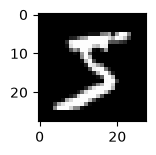

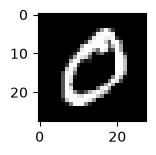

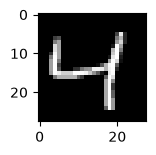

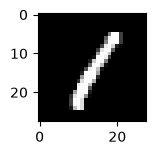

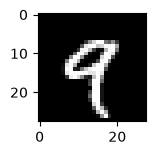

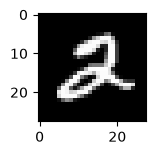

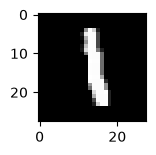

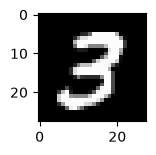

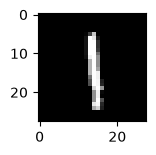

In [5]:
for i in range(9):
    # We used 330, because first 3 shows row, second 3 shows columns, and 0 shows value change...
    plt.subplot(330+1+i)
    plt.imshow(X_train[i], cmap=plt.get_cmap('gray'))
    plt.show()

In [6]:
# Create model
model = keras.models.Sequential([keras.layers.Flatten(input_shape=(28, 28)),
                                 keras.layers.Dense(128, activation='relu'),
                                 keras.layers.Dense(10, )])
print(model.summary())

c:\Users\mrgam\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

None


In [7]:
# Loss and Optimizer
loss = keras.losses.SparseCategoricalCrossentropy(from_logits=True)
optim = keras.optimizers.Adam()
metrics = ['accuracy']
model.compile(loss=loss, optimizer=optim, metrics=metrics)

In [20]:
# Model Train
batch_size = 64
epochs = 5
history = model.fit(X_train, y_train, batch_size=batch_size, epochs=epochs, validation_data=(X_test, y_test), shuffle=True, verbose=2)

Epoch 1/5
938/938 - 4s - 4ms/step - accuracy: 0.9687 - loss: 0.1267 - val_accuracy: 0.9548 - val_loss: 0.3072
Epoch 2/5
938/938 - 3s - 3ms/step - accuracy: 0.9708 - loss: 0.1183 - val_accuracy: 0.9569 - val_loss: 0.3022
Epoch 3/5
938/938 - 3s - 3ms/step - accuracy: 0.9726 - loss: 0.1084 - val_accuracy: 0.9565 - val_loss: 0.3163
Epoch 4/5
938/938 - 3s - 3ms/step - accuracy: 0.9732 - loss: 0.1144 - val_accuracy: 0.9547 - val_loss: 0.3105
Epoch 5/5
938/938 - 3s - 3ms/step - accuracy: 0.9732 - loss: 0.1158 - val_accuracy: 0.9533 - val_loss: 0.3360


In [10]:
# Evaluation
model.evaluate(X_test, y_test, batch_size=batch_size, verbose=2)

157/157 - 0s - 2ms/step - accuracy: 0.9575 - loss: 0.2171


[0.2170519083738327, 0.9574999809265137]

In [11]:
# Predictions
predictions = model.predict(X_test, batch_size=batch_size)
print(predictions)

157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
[[  36.015575   72.66791    79.40743  ...  109.52496    47.77001
    79.11828 ]
 [  16.209715  174.21039   187.20412  ...   83.55664    71.17591
   -37.44868 ]
 [  -7.260662   73.61032    47.446594 ...   49.860916   43.385395
    19.620607]
 ...
 [ -16.798252    8.84725   -14.003744 ...   32.731003   30.505816
    36.46666 ]
 [ -15.143953  -24.36272  -101.377556 ...   -2.908299   67.15772
   -56.56276 ]
 [  61.235893   28.549995   71.65122  ...  -16.360054   64.95815
    46.858166]]


In [12]:
predictions = tf.nn.softmax(predictions)
print(predictions.shape)

(10000, 10)


In [16]:
print(np.argmax(predictions[8]))

6


dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


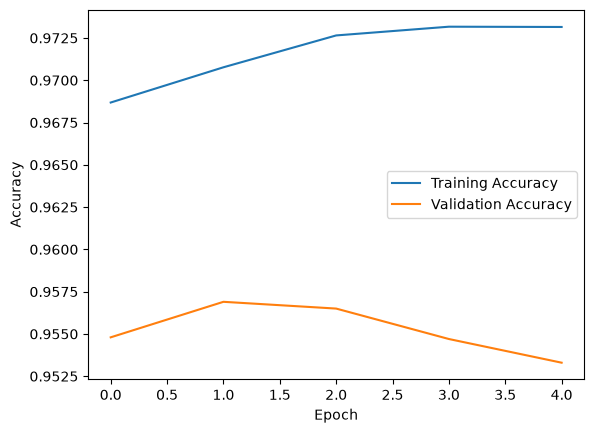

In [21]:
# Plotting
print(history.history.keys())
plt.plot(history.history['accuracy'], label="Training Accuracy")
plt.plot(history.history['val_accuracy'], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


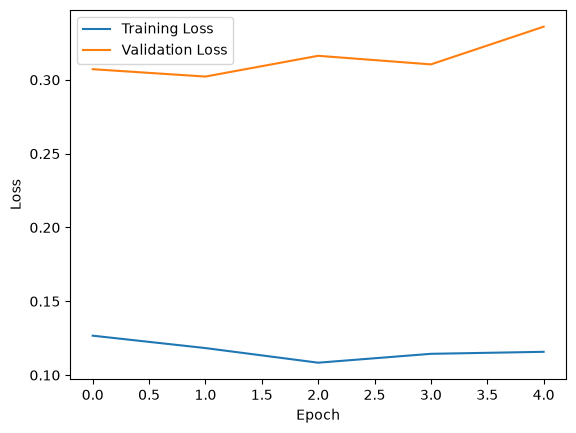

In [22]:
# Plotting
print(history.history.keys())
plt.plot(history.history['loss'], label="Training Loss")
plt.plot(history.history['val_loss'], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

I got lower accuracy and higher loss on validation due to increasing epochs, which is a sign of overfitting. The model is learning the training data too well and not generalizing to new data.